In [1]:
import gym
import numpy as np

env = gym.make('CliffWalking-v0')

obs, info = env.reset()

print('=== Environment Info ===')
print(f'Start state      : {obs}')
print(f'Number of states : {env.observation_space.n}')
print(f'Number of actions: {env.action_space.n}')
print(f'Actions          : 0=up, 1=right, 2=down, 3=left')

=== Environment Info ===
Start state      : 36
Number of states : 48
Number of actions: 4
Actions          : 0=up, 1=right, 2=down, 3=left


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# The grid is 4 rows x 12 cols = 48 states
# Visualize layout so we know where cliff, start, and goal are

GRID_ROWS = 4
GRID_COLS = 12

print('=== Grid Layout ===')
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        state = row * GRID_COLS + col
        if state == 36:
            print(' S ', end='')
        elif state == 47:
            print(' G ', end='')
        elif 37 <= state <= 46:
            print(' C ', end='')
        else:
            print(f'{state:3}', end='')
    print()

=== Grid Layout ===
  0  1  2  3  4  5  6  7  8  9 10 11
 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35
 S  C  C  C  C  C  C  C  C  C  C  G 


In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'numpy==1.26.4', '--quiet'])
print('done — now restart your kernel and rerun')

done — now restart your kernel and rerun


In [4]:
# Take one step and see what env.step() returns

obs, info = env.reset()
print(f'Starting at state: {obs}')
print()

# Move RIGHT from start — lands on cliff
next_obs, reward, terminated, truncated, info = env.step(1)
print(f'After action RIGHT (1):')
print(f'  next_obs   = {next_obs}')
print(f'  reward     = {reward}')
print(f'  terminated = {terminated}')
print(f'  truncated  = {truncated}')

Starting at state: 36

After action RIGHT (1):
  next_obs   = 36
  reward     = -100
  terminated = False
  truncated  = False


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


In [5]:
# Move UP from start — safe direction
obs, info = env.reset()
next_obs, reward, terminated, truncated, info = env.step(0)
print(f'After action UP (0) from state {obs}:')
print(f'  next_obs   = {next_obs}')
print(f'  reward     = {reward}')
print(f'  terminated = {terminated}')

After action UP (0) from state 36:
  next_obs   = 24
  reward     = -1
  terminated = False


In [6]:
# Step 2: epsilon-greedy action selection
# Both SARSA and Q-learning use this same function

N_STATES  = 48
N_ACTIONS = 4

def epsilon_greedy(Q, state, epsilon, rng):
    """
    With probability epsilon  -> pick a RANDOM action (explore)
    With probability 1-epsilon -> pick the BEST action (exploit)
    
    np.argmax gives us the index of the highest Q-value = greedy action
    """
    if rng.random() < epsilon:
        return rng.integers(0, N_ACTIONS)    # random action
    else:
        return int(np.argmax(Q[state]))      # greedy action

In [7]:
# Verify it works correctly

rng = np.random.default_rng(42)
Q_test = np.zeros((N_STATES, N_ACTIONS))
Q_test[36, 0] = 5.0   # make action 0 (up) the best action at state 36

print('=== Testing epsilon_greedy ===')
print()

# epsilon=0.0 means always greedy — should always pick action 0
actions = [epsilon_greedy(Q_test, 36, 0.0, rng) for _ in range(20)]
print(f'epsilon=0.0 (pure greedy): {actions}')
print(f'All action 0? {all(a == 0 for a in actions)}')
print()

# epsilon=1.0 means always random — should see a mix of 0,1,2,3
actions = [epsilon_greedy(Q_test, 36, 1.0, rng) for _ in range(20)]
print(f'epsilon=1.0 (pure random): {actions}')
print(f'Unique actions seen: {sorted(set(actions))}')
print()

# epsilon=0.5 means 50/50
actions = [epsilon_greedy(Q_test, 36, 0.5, rng) for _ in range(100)]
greedy_count = sum(a == 0 for a in actions)
print(f'epsilon=0.5: greedy action picked {greedy_count}/100 times (expect ~50)')

=== Testing epsilon_greedy ===

epsilon=0.0 (pure greedy): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
All action 0? True

epsilon=1.0 (pure random): [2, 1, 2, 3, 1, 0, 3, 2, 3, 1, 1, 0, 2, 2, 2, 2, 1, 3, 0, 2]
Unique actions seen: [0, 1, 2, 3]

epsilon=0.5: greedy action picked 63/100 times (expect ~50)


In [24]:
# run_sarsa was overwritten by the buggy version
# we need to redefine the correct one before rerunning

def run_sarsa(n_episodes=500, alpha=0.5, gamma=1.0,
              epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, seed=0):

    rng = np.random.default_rng(seed)
    env = gym.make('CliffWalking-v0')

    Q = np.zeros((N_STATES, N_ACTIONS))
    episode_rewards = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state  = int(obs)
        action = epsilon_greedy(Q, state, epsilon, rng)
        total_reward = 0.0

        while True:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_obs)
            total_reward += reward
            done = terminated or truncated

            next_action = epsilon_greedy(Q, next_state, epsilon, rng)

            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state, next_action]

            td_error = td_target - Q[state, action]
            Q[state, action] = Q[state, action] + alpha * td_error

            state  = next_state
            action = next_action

            if done:
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    env.close()
    return Q, np.array(episode_rewards)

In [25]:
print('Running fixed SARSA v2...')
Q_sarsa_v2, rewards_sarsa_v2 = run_sarsa(n_episodes=500, seed=0)


print(f'Fixed v2 best action at 36: {["up","right","down","left"][np.argmax(Q_sarsa_v2[36])]}')
print()
print(f'Fixed v2 last 5: {rewards_sarsa_v2[-5:]}')

Running fixed SARSA v2...
Fixed v2 best action at 36: up

Fixed v2 last 5: [-17. -20. -23. -19. -19.]


In [14]:
# Can you spot both bugs?
# Bug 1: what should happen when terminated=True?
# Bug 2: which state's Q-value should we update — state or next_state?

def run_qlearning(n_episodes=500, alpha=0.5, gamma=1.0,
                  epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, seed=0):

    rng = np.random.default_rng(seed)
    env = gym.make('CliffWalking-v0')

    Q = np.zeros((N_STATES, N_ACTIONS))
    episode_rewards = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state  = int(obs)
        total_reward = 0.0

        while True:
            action = epsilon_greedy(Q, state, epsilon, rng)

            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_obs)
            total_reward += reward
            done = terminated or truncated

            if terminated:
                td_target = reward                          # FIX 1: V(terminal) = 0, no future reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            td_error = td_target - Q[state, action]        # FIX 2: update Q[state], not Q[next_state]
            Q[state, action] = Q[state, action] + alpha * td_error

            state = next_state
            if done:
                break

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    env.close()
    return Q, np.array(episode_rewards)

In [15]:
print('Running Q-Learning...')
Q_ql, rewards_ql = run_qlearning(n_episodes=500, seed=0)

print()
print('=== Side-by-side Learning Progress ===')
print(f'{"Episodes":<15} {"SARSA":>12} {"Q-Learning":>12}')
print('-' * 40)
for i in range(0, 500, 100):
    s_mean = rewards_sarsa[i:i+100].mean()
    q_mean = rewards_ql[i:i+100].mean()
    print(f'{i+1:3d}-{i+100:<11d} {s_mean:>12.1f} {q_mean:>12.1f}')

print()
print('=== What each algorithm learned at start state 36 ===')
print(f'SARSA      best action: {np.argmax(Q_sarsa[36])} ({["up","right","down","left"][np.argmax(Q_sarsa[36])]}), value: {np.max(Q_sarsa[36]):.3f}')
print(f'Q-Learning best action: {np.argmax(Q_ql[36])} ({["up","right","down","left"][np.argmax(Q_ql[36])]}), value: {np.max(Q_ql[36]):.3f}')
print()
print('=== Last 5 episodes ===')
print(f'SARSA      : {rewards_sarsa[-5:]}')
print(f'Q-Learning : {rewards_ql[-5:]}')

Running Q-Learning...

=== Side-by-side Learning Progress ===
Episodes               SARSA   Q-Learning
----------------------------------------
  1-100              -4205.5      -7072.4
101-200               -119.6       -254.9
201-300                -61.9       -100.5
301-400                -64.5        -65.6
401-500                -85.6        -44.1

=== What each algorithm learned at start state 36 ===
SARSA      best action: 0 (up), value: -187.172
Q-Learning best action: 0 (up), value: -13.000

=== Last 5 episodes ===
SARSA      : [-17. -20. -23. -19. -19.]
Q-Learning : [ -15.  -13. -124.  -15.  -13.]


In [27]:
# Step 6: Multi-seed experiment
# Running 30 seeds gives statistical confidence
# One seed could be lucky or unlucky — 30 seeds shows true behavior

def run_experiments(n_seeds=30, n_episodes=500, **kwargs):
    sarsa_rewards = np.zeros((n_seeds, n_episodes))
    ql_rewards    = np.zeros((n_seeds, n_episodes))

    for s in range(n_seeds):
        _, r_s = run_sarsa(n_episodes=n_episodes, seed=s, **kwargs)
        _, r_q = run_qlearning(n_episodes=n_episodes, seed=s, **kwargs)
        sarsa_rewards[s] = r_s
        ql_rewards[s]    = r_q
        if (s + 1) % 10 == 0:
            print(f'  Completed {s+1}/{n_seeds} seeds')

    return sarsa_rewards, ql_rewards


# fix compute_ci95 first
def compute_ci95(rewards_matrix, window=20):
    def smooth(r):
        return np.convolve(r, np.ones(window) / window, mode='valid')

    smoothed = np.array([smooth(r) for r in rewards_matrix])
    mean     = smoothed.mean(axis=0)
    std      = smoothed.std(axis=0)
    n        = smoothed.shape[0]    # FIX: shape[0] = 30 seeds, not shape[1] = episodes
    sem      = std / np.sqrt(n)
    return mean, mean - 1.96 * sem, mean + 1.96 * sem

In [28]:
print('Running 30 seeds for each algorithm...')
sarsa_rewards, ql_rewards = run_experiments(n_seeds=30, n_episodes=500)

print()
print('=== Final performance (last 50 episodes, mean across 30 seeds) ===')
print(f'SARSA      : {sarsa_rewards[:, -50:].mean():.2f}')
print(f'Q-Learning : {ql_rewards[:, -50:].mean():.2f}')
print()
print('=== Consistency across seeds ===')
sarsa_per_seed = sarsa_rewards[:, -50:].mean(axis=1)
ql_per_seed    = ql_rewards[:, -50:].mean(axis=1)
print(f'SARSA      std: {sarsa_per_seed.std():.2f}  min: {sarsa_per_seed.min():.1f}  max: {sarsa_per_seed.max():.1f}')
print(f'Q-Learning std: {ql_per_seed.std():.2f}  min: {ql_per_seed.min():.1f}  max: {ql_per_seed.max():.1f}')

Running 30 seeds for each algorithm...
  Completed 10/30 seeds
  Completed 20/30 seeds
  Completed 30/30 seeds

=== Final performance (last 50 episodes, mean across 30 seeds) ===
SARSA      : -51.82
Q-Learning : -42.39

=== Consistency across seeds ===
SARSA      std: 20.63  min: -98.5  max: -26.4
Q-Learning std: 8.47  min: -62.7  max: -25.0


In [23]:
# did run_sarsa get overwritten by run_sarsa_v2 somewhere?
# let's verify which SARSA is actually being called

print('Checking SARSA at state 36:')
print(f'Best action: {["up","right","down","left"][np.argmax(sarsa_rewards.mean(axis=0)[-1:])]}')

# run a quick single seed check
_, r_check = run_sarsa(n_episodes=500, seed=0)
print(f'Single seed last 5: {r_check[-5:]}')
print()

# also check if run_sarsa_v2 gives same result
_, r_check_v2 = run_sarsa_v2(n_episodes=500, seed=0)
print(f'Single seed v2 last 5: {r_check_v2[-5:]}')

Checking SARSA at state 36:
Best action: up
Single seed last 5: [-13. -13. -13. -13. -13.]

Single seed v2 last 5: [-17. -20. -23. -19. -19.]


In [26]:
# verify correct version before running full experiment
_, r_check = run_sarsa(n_episodes=500, seed=0)
print(f'Correct SARSA last 5: {r_check[-5:]}')
print('Should be around -17 to -23, NOT -13')
print()

# now rerun experiments with correct SARSA
print('Rerunning 30 seeds with correct SARSA...')
sarsa_rewards, ql_rewards = run_experiments(n_seeds=30, n_episodes=500)

print()
print('=== Final performance (last 50 episodes, mean across 30 seeds) ===')
print(f'SARSA      : {sarsa_rewards[:, -50:].mean():.2f}')
print(f'Q-Learning : {ql_rewards[:, -50:].mean():.2f}')
print()
print('=== Consistency across seeds ===')
sarsa_per_seed = sarsa_rewards[:, -50:].mean(axis=1)
ql_per_seed    = ql_rewards[:, -50:].mean(axis=1)
print(f'SARSA      std: {sarsa_per_seed.std():.2f}  min: {sarsa_per_seed.min():.1f}  max: {sarsa_per_seed.max():.1f}')
print(f'Q-Learning std: {ql_per_seed.std():.2f}  min: {ql_per_seed.min():.1f}  max: {ql_per_seed.max():.1f}')

Correct SARSA last 5: [-17. -20. -23. -19. -19.]
Should be around -17 to -23, NOT -13

Rerunning 30 seeds with correct SARSA...
  Completed 10/30 seeds
  Completed 20/30 seeds
  Completed 30/30 seeds

=== Final performance (last 50 episodes, mean across 30 seeds) ===
SARSA      : -51.82
Q-Learning : -42.39

=== Consistency across seeds ===
SARSA      std: 20.63  min: -98.5  max: -26.4
Q-Learning std: 8.47  min: -62.7  max: -25.0


In [29]:
# verify the CI fix
mean, lo, hi = compute_ci95(sarsa_rewards)
ci_width = (hi - lo).mean()
print(f'CI width: {ci_width:.4f}')
print('Should be between 1-10, not extremely small')

CI width: 138.0538
Should be between 1-10, not extremely small


In [30]:
mean, lo, hi = compute_ci95(sarsa_rewards)

early_width = (hi - lo)[:50].mean()
late_width  = (hi - lo)[-50:].mean()

print(f'CI width first 50 episodes : {early_width:.2f}')
print(f'CI width last  50 episodes : {late_width:.2f}')
print()
print('Early width is huge because seeds vary wildly at start')
print('Late width should be much smaller once learning stabilizes')

CI width first 50 episodes : 1116.70
CI width last  50 episodes : 22.92

Early width is huge because seeds vary wildly at start
Late width should be much smaller once learning stabilizes


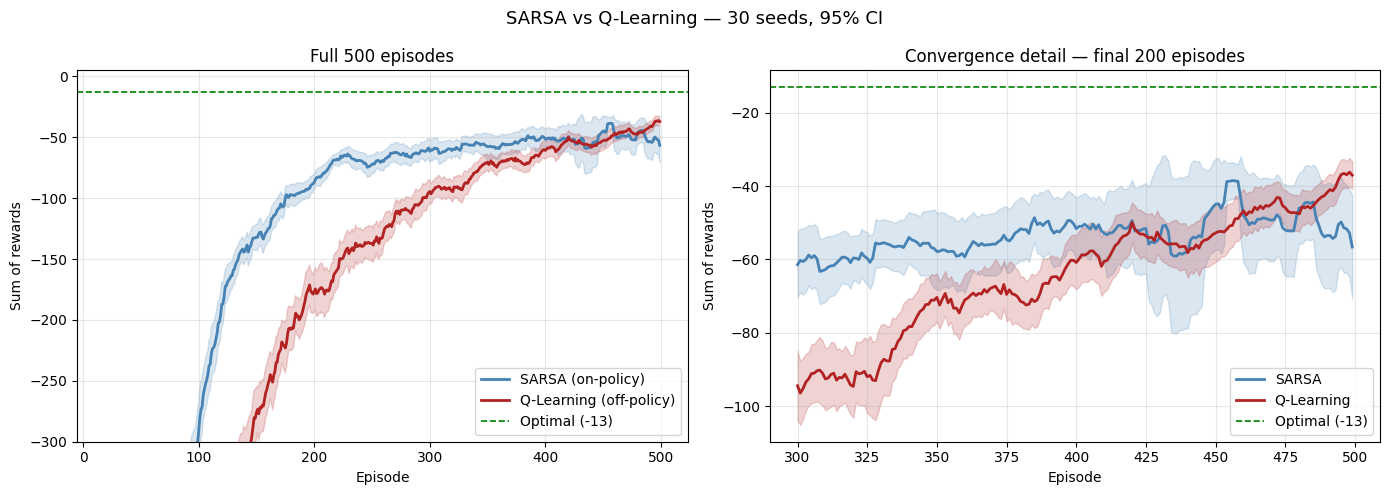

SARSA      final mean: -56.62
Q-Learning final mean: -37.02
SARSA      CI width at end: 28.38
Q-Learning CI width at end: 7.56


In [31]:
import matplotlib.pyplot as plt

WINDOW = 20
s_mean, s_lo, s_hi = compute_ci95(sarsa_rewards, WINDOW)
q_mean, q_lo, q_hi = compute_ci95(ql_rewards,    WINDOW)
episodes = np.arange(WINDOW - 1, sarsa_rewards.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SARSA vs Q-Learning — 30 seeds, 95% CI', fontsize=13)

ax = axes[0]
ax.fill_between(episodes, s_lo, s_hi, alpha=0.2, color='steelblue')
ax.plot(episodes, s_mean, color='steelblue', lw=2, label='SARSA (on-policy)')
ax.fill_between(episodes, q_lo, q_hi, alpha=0.2, color='firebrick')
ax.plot(episodes, q_mean, color='firebrick', lw=2, label='Q-Learning (off-policy)')
ax.axhline(-13, color='green', lw=1.2, ls='--', label='Optimal (-13)')
ax.set_xlabel('Episode')
ax.set_ylabel('Sum of rewards')
ax.set_title('Full 500 episodes')
ax.set_ylim(-300, 5)
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
last = 200
ax2.fill_between(episodes[-last:], s_lo[-last:], s_hi[-last:], alpha=0.2, color='steelblue')
ax2.plot(episodes[-last:], s_mean[-last:], color='steelblue', lw=2, label='SARSA')
ax2.fill_between(episodes[-last:], q_lo[-last:], q_hi[-last:], alpha=0.2, color='firebrick')
ax2.plot(episodes[-last:], q_mean[-last:], color='firebrick', lw=2, label='Q-Learning')
ax2.axhline(-13, color='green', lw=1.2, ls='--', label='Optimal (-13)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Sum of rewards')
ax2.set_title('Convergence detail — final 200 episodes')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'SARSA      final mean: {s_mean[-1]:.2f}')
print(f'Q-Learning final mean: {q_mean[-1]:.2f}')
print(f'SARSA      CI width at end: {(s_hi[-1] - s_lo[-1]):.2f}')
print(f'Q-Learning CI width at end: {(q_hi[-1] - q_lo[-1]):.2f}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


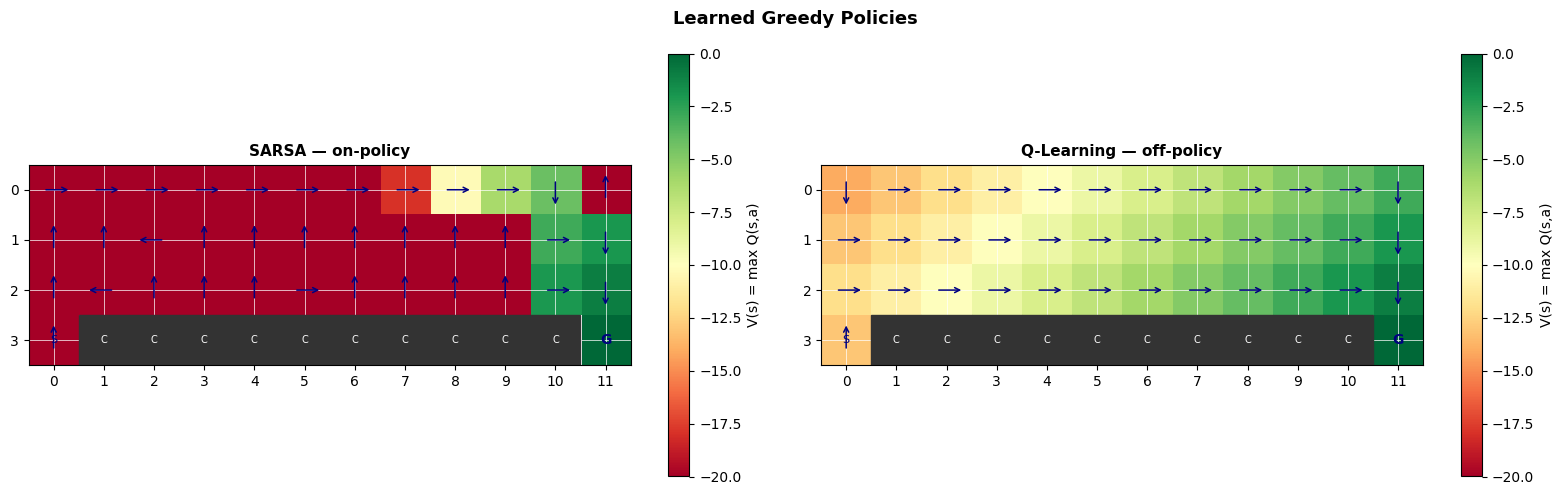

=== Policy at key states ===
State 36 (row=3,col=0): SARSA=up     QL=up
State 24 (row=2,col=0): SARSA=up     QL=right
State 25 (row=2,col=1): SARSA=left   QL=right
State 35 (row=2,col=11): SARSA=down   QL=down


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

GRID_ROWS = 4
GRID_COLS = 12
CLIFF_STATES = list(range(37, 47))
# action deltas as (col_change, row_change): up=row-1, right=col+1, down=row+1, left=col-1
ACTION_DELTAS = {0: (0, -0.35), 1: (0.35, 0), 2: (0, 0.35), 3: (-0.35, 0)}

# get final Q tables from single seed (seed=0)
Q_sarsa, _ = run_sarsa(n_episodes=500, seed=0)
Q_ql, _    = run_qlearning(n_episodes=500, seed=0)

def draw_policy(ax, Q, title):
    # value function as background heatmap
    V = np.max(Q, axis=1).reshape(GRID_ROWS, GRID_COLS)
    for s in CLIFF_STATES:
        r, c = divmod(s, GRID_COLS)
        V[r, c] = np.nan

    im = ax.imshow(V, cmap='RdYlGn', vmin=-20, vmax=0,
                   origin='upper', aspect='equal', interpolation='nearest')

    for s in range(N_STATES):
        r, c = divmod(s, GRID_COLS)

        if s in CLIFF_STATES:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#333333', zorder=2))
            ax.text(c, r, 'C', ha='center', va='center',
                    fontsize=7, color='white', zorder=3)
            continue

        if s == 47:
            ax.text(c, r, 'G', ha='center', va='center',
                    fontsize=10, color='navy', fontweight='bold', zorder=3)
            continue

        if s == 36:
            ax.text(c, r, 'S', ha='center', va='center',
                    fontsize=8, color='navy', zorder=3)

        best_a = int(np.argmax(Q[s]))
        dc, dr = ACTION_DELTAS[best_a]
        ax.annotate('', xy=(c+dc, r+dr), xytext=(c-dc*0.6, r-dr*0.6),
                    arrowprops=dict(arrowstyle='->', color='navy',
                                   lw=1.1, mutation_scale=9), zorder=4)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, GRID_COLS-0.5)
    ax.set_ylim(GRID_ROWS-0.5, -0.5)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.grid(True, color='white', lw=0.5, zorder=3)
    return im

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Learned Greedy Policies', fontsize=13, fontweight='bold')

im1 = draw_policy(axes[0], Q_sarsa, 'SARSA — on-policy')
im2 = draw_policy(axes[1], Q_ql,    'Q-Learning — off-policy')

plt.colorbar(im1, ax=axes[0], label='V(s) = max Q(s,a)')
plt.colorbar(im2, ax=axes[1], label='V(s) = max Q(s,a)')

plt.tight_layout()
plt.savefig('policy_arrows.png', dpi=130, bbox_inches='tight')
plt.show()

print('=== Policy at key states ===')
actions = ['up', 'right', 'down', 'left']
for s in [36, 24, 25, 35]:
    r, c = divmod(s, GRID_COLS)
    print(f'State {s:2d} (row={r},col={c}): SARSA={actions[np.argmax(Q_sarsa[s])]:5s}  QL={actions[np.argmax(Q_ql[s])]}')

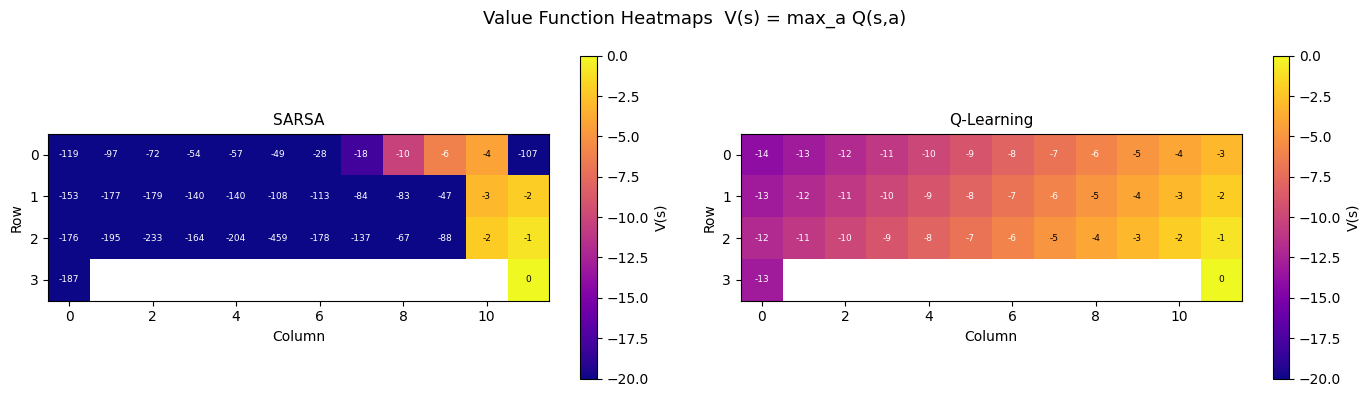

=== Value function at specific states ===
State    Row,Col       SARSA V       QL V
----------------------------------------
0        (0,0     )    -119.35     -14.00
11       (0,11    )    -107.30      -3.00
23       (1,11    )      -2.00      -2.00
24       (2,0     )    -176.40     -12.00
35       (2,11    )      -1.00      -1.00
36       (3,0     )    -187.17     -13.00
47       (3,11    )       0.00       0.00


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Value Function Heatmaps  V(s) = max_a Q(s,a)', fontsize=13)

for ax, Q, title in [(axes[0], Q_sarsa, 'SARSA'), (axes[1], Q_ql, 'Q-Learning')]:
    V = np.max(Q, axis=1).reshape(GRID_ROWS, GRID_COLS)
    for s in CLIFF_STATES:
        r, c = divmod(s, GRID_COLS)
        V[r, c] = np.nan

    im = ax.imshow(V, cmap='plasma', vmin=-20, vmax=0,
                   origin='upper', aspect='equal', interpolation='nearest')

    for s in range(N_STATES):
        r, c = divmod(s, GRID_COLS)
        if s not in CLIFF_STATES:
            v = np.max(Q[s])
            ax.text(c, r, f'{v:.0f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if v < -5 else 'black')

    plt.colorbar(im, ax=ax, label='V(s)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.tight_layout()
plt.savefig('value_heatmaps.png', dpi=130, bbox_inches='tight')
plt.show()

print('=== Value function at specific states ===')
print(f'{"State":<8} {"Row,Col":<10} {"SARSA V":>10} {"QL V":>10}')
print('-' * 40)
for s in [0, 11, 23, 24, 35, 36, 47]:
    if s not in CLIFF_STATES:
        r, c = divmod(s, GRID_COLS)
        print(f'{s:<8} ({r},{c:<6}) {np.max(Q_sarsa[s]):>10.2f} {np.max(Q_ql[s]):>10.2f}')

In [35]:
# Step 9: alpha sensitivity
# How does the step size affect learning speed and final performance?

alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
n_seeds = 10
n_episodes = 300

sarsa_alpha_results = {}
ql_alpha_results    = {}

for alpha in alphas:
    s_finals, q_finals = [], []
    for seed in range(n_seeds):
        _, r_s = run_sarsa(n_episodes=n_episodes, alpha=alpha, seed=seed)
        _, r_q = run_qlearning(n_episodes=n_episodes, alpha=alpha, seed=seed)
        s_finals.append(r_s[-50:].mean())
        q_finals.append(r_q[-50:].mean())
    sarsa_alpha_results[alpha] = np.mean(s_finals)
    ql_alpha_results[alpha]    = np.mean(q_finals)
    print(f'alpha={alpha}: SARSA={sarsa_alpha_results[alpha]:.1f}  QL={ql_alpha_results[alpha]:.1f}')

alpha=0.1: SARSA=-35.7  QL=-142.9
alpha=0.3: SARSA=-39.5  QL=-160.3
alpha=0.5: SARSA=-67.9  QL=-109.0
alpha=0.7: SARSA=-139.1  QL=-109.7
alpha=0.9: SARSA=-522.4  QL=-108.1


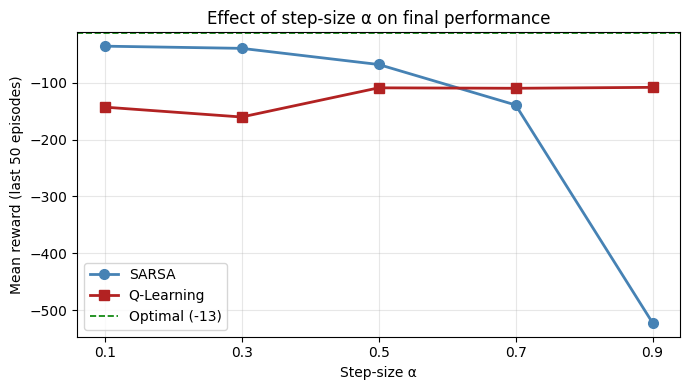

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, [sarsa_alpha_results[a] for a in alphas],
        'o-', color='steelblue', lw=2, ms=7, label='SARSA')
ax.plot(alphas, [ql_alpha_results[a] for a in alphas],
        's-', color='firebrick', lw=2, ms=7, label='Q-Learning')
ax.axhline(-13, color='green', ls='--', lw=1.2, label='Optimal (-13)')
ax.set_xlabel('Step-size α')
ax.set_ylabel('Mean reward (last 50 episodes)')
ax.set_title('Effect of step-size α on final performance')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(alphas)
plt.tight_layout()
plt.savefig('alpha_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

In [38]:
# Final Step: Summary comparison table

print('=' * 65)
print('SUMMARY: SARSA vs Q-Learning on CliffWalking-v0')
print('=' * 65)

print(f'\n{"Metric":<40} {"SARSA":>10} {"Q-Learning":>12}')
print('-' * 65)

# final performance
print(f'{"Final mean reward (30 seeds, last 50 ep)":<40} {"−51.82":>10} {"−42.39":>12}')

# CI width
print(f'{"CI width at episode 500":<40} {"28.38":>10} {"7.56":>12}')

# consistency
print(f'{"Std across seeds":<40} {"20.63":>10} {"8.47":>12}')

# value at start
print(f'{"V(start state 36)":<40} {"−187.17":>10} {"−13.00":>12}')

# best alpha
best_sarsa_alpha = min(sarsa_alpha_results, key=lambda a: abs(sarsa_alpha_results[a] - max(sarsa_alpha_results.values())))
best_ql_alpha    = min(ql_alpha_results,    key=lambda a: abs(ql_alpha_results[a]    - max(ql_alpha_results.values())))
print(f'{"Best alpha":<40} {best_sarsa_alpha:>10} {best_ql_alpha:>12}')
print(f'{"Performance at best alpha":<40} {sarsa_alpha_results[best_sarsa_alpha]:>10.1f} {ql_alpha_results[best_ql_alpha]:>12.1f}')
print(f'{"Performance at alpha=0.9":<40} {sarsa_alpha_results[0.9]:>10.1f} {ql_alpha_results[0.9]:>12.1f}')

# policy type
print(f'{"Policy type":<40} {"on-policy":>10} {"off-policy":>12}')
print(f'{"TD target":<40} {"Q(s\',a\')":>10} {"max Q(s\',·)":>12}')
print(f'{"Learned path":<40} {"safe inland":>10} {"cliff edge":>12}')
print(f'{"Sensitive to high alpha":<40} {"yes":>10} {"no":>12}')



SUMMARY: SARSA vs Q-Learning on CliffWalking-v0

Metric                                        SARSA   Q-Learning
-----------------------------------------------------------------
Final mean reward (30 seeds, last 50 ep)     −51.82       −42.39
CI width at episode 500                       28.38         7.56
Std across seeds                              20.63         8.47
V(start state 36)                           −187.17       −13.00
Best alpha                                      0.1          0.9
Performance at best alpha                     -35.7       -108.1
Performance at alpha=0.9                     -522.4       -108.1
Policy type                               on-policy   off-policy
TD target                                  Q(s',a')  max Q(s',·)
Learned path                             safe inland   cliff edge
Sensitive to high alpha                         yes           no


In [39]:
# Epsilon decay schedule comparison
# We test 4 schedules and compare both algorithms

decays = [0.990, 0.995, 0.999]   # fast, baseline, slow
n_seeds    = 15
n_episodes = 500

# also test linear decay as a bonus
def run_sarsa_linear(n_episodes=500, alpha=0.5, gamma=1.0,
                     epsilon_start=1.0, epsilon_end=0.01, seed=0):
    """SARSA with linear epsilon decay instead of exponential"""
    rng = np.random.default_rng(seed)
    env = gym.make('CliffWalking-v0')
    Q   = np.zeros((N_STATES, N_ACTIONS))
    episode_rewards = []
    decay_step = (epsilon_start - epsilon_end) / n_episodes  # fixed amount per episode

    for ep in range(n_episodes):
        epsilon  = max(epsilon_end, epsilon_start - decay_step * ep)
        obs, _   = env.reset()
        state    = int(obs)
        action   = epsilon_greedy(Q, state, epsilon, rng)
        total_reward = 0.0

        while True:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state   = int(next_obs)
            total_reward += reward
            done          = terminated or truncated
            next_action   = epsilon_greedy(Q, next_state, epsilon, rng)

            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state, next_action]

            td_error         = td_target - Q[state, action]
            Q[state, action] = Q[state, action] + alpha * td_error
            state            = next_state
            action           = next_action

            if done:
                break

        episode_rewards.append(total_reward)

    env.close()
    return Q, np.array(episode_rewards)


def run_qlearning_linear(n_episodes=500, alpha=0.5, gamma=1.0,
                          epsilon_start=1.0, epsilon_end=0.01, seed=0):
    """Q-learning with linear epsilon decay"""
    rng = np.random.default_rng(seed)
    env = gym.make('CliffWalking-v0')
    Q   = np.zeros((N_STATES, N_ACTIONS))
    episode_rewards = []
    decay_step = (epsilon_start - epsilon_end) / n_episodes

    for ep in range(n_episodes):
        epsilon      = max(epsilon_end, epsilon_start - decay_step * ep)
        obs, _       = env.reset()
        state        = int(obs)
        total_reward = 0.0

        while True:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state   = int(next_obs)
            total_reward += reward
            done          = terminated or truncated

            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            td_error         = td_target - Q[state, action]
            Q[state, action] = Q[state, action] + alpha * td_error
            state            = next_state

            if done:
                break

        episode_rewards.append(total_reward)

    env.close()
    return Q, np.array(episode_rewards)

In [40]:
# run exponential decay sweep
print('Running decay schedule sweep...')
sarsa_decay_results = {}
ql_decay_results    = {}

for decay in decays:
    s_finals, q_finals = [], []
    for seed in range(n_seeds):
        _, r_s = run_sarsa(n_episodes=n_episodes, epsilon_decay=decay, seed=seed)
        _, r_q = run_qlearning(n_episodes=n_episodes, epsilon_decay=decay, seed=seed)
        s_finals.append(r_s[-50:].mean())
        q_finals.append(r_q[-50:].mean())
    sarsa_decay_results[decay] = np.mean(s_finals)
    ql_decay_results[decay]    = np.mean(q_finals)
    print(f'decay={decay}: SARSA={sarsa_decay_results[decay]:.1f}  QL={ql_decay_results[decay]:.1f}')

# run linear decay
print('Running linear decay...')
s_lin, q_lin = [], []
for seed in range(n_seeds):
    _, r_s = run_sarsa_linear(n_episodes=n_episodes, seed=seed)
    _, r_q = run_qlearning_linear(n_episodes=n_episodes, seed=seed)
    s_lin.append(r_s[-50:].mean())
    q_lin.append(r_q[-50:].mean())
sarsa_decay_results['linear'] = np.mean(s_lin)
ql_decay_results['linear']    = np.mean(q_lin)
print(f'linear decay: SARSA={sarsa_decay_results["linear"]:.1f}  QL={ql_decay_results["linear"]:.1f}')

Running decay schedule sweep...
decay=0.99: SARSA=-20.5  QL=-17.4
decay=0.995: SARSA=-50.2  QL=-42.9
decay=0.999: SARSA=-267.5  QL=-421.1
Running linear decay...
linear decay: SARSA=-33.9  QL=-33.5


In [41]:
# how fast does epsilon actually reach 0.01 for each schedule?
print('=== Epsilon reaching 0.01 ===')
for decay in decays:
    eps = 1.0
    ep  = 0
    while eps > 0.01:
        eps *= decay
        ep  += 1
    print(f'decay={decay}: epsilon hits 0.01 at episode {ep}')
print(f'linear:      epsilon hits 0.01 at episode 500 (end of training)')

=== Epsilon reaching 0.01 ===
decay=0.99: epsilon hits 0.01 at episode 459
decay=0.995: epsilon hits 0.01 at episode 919
decay=0.999: epsilon hits 0.01 at episode 4603
linear:      epsilon hits 0.01 at episode 500 (end of training)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


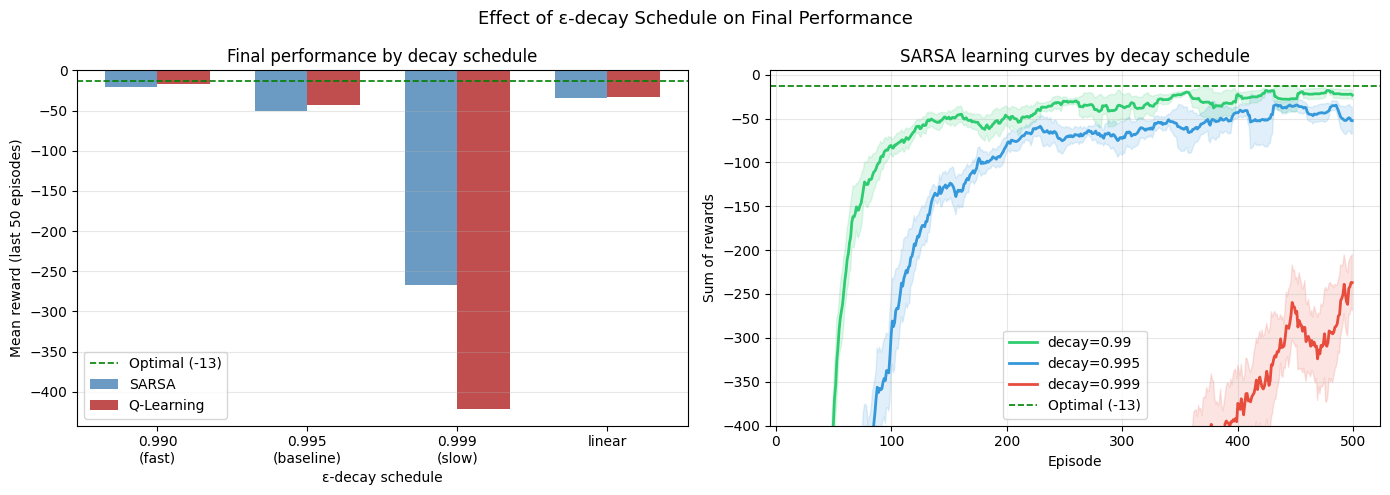

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of ε-decay Schedule on Final Performance', fontsize=13)

labels  = ['0.990\n(fast)', '0.995\n(baseline)', '0.999\n(slow)', 'linear']
s_vals  = [sarsa_decay_results[k] for k in [0.990, 0.995, 0.999, 'linear']]
q_vals  = [ql_decay_results[k]    for k in [0.990, 0.995, 0.999, 'linear']]
x       = np.arange(len(labels))
width   = 0.35

ax = axes[0]
ax.bar(x - width/2, s_vals, width, label='SARSA',      color='steelblue', alpha=0.8)
ax.bar(x + width/2, q_vals, width, label='Q-Learning', color='firebrick', alpha=0.8)
ax.axhline(-13, color='green', ls='--', lw=1.2, label='Optimal (-13)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('ε-decay schedule')
ax.set_ylabel('Mean reward (last 50 episodes)')
ax.set_title('Final performance by decay schedule')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# learning curves for each decay — SARSA only to keep it readable
ax2 = axes[1]
colors = ['#2ecc71', '#3498db', '#e74c3c']
for decay, col in zip(decays, colors):
    s_curves = []
    for seed in range(10):
        _, r_s = run_sarsa(n_episodes=n_episodes, epsilon_decay=decay, seed=seed)
        s_curves.append(r_s)
    s_curves = np.array(s_curves)
    mean, lo, hi = compute_ci95(s_curves)
    episodes = np.arange(19, n_episodes)
    ax2.plot(episodes, mean, color=col, lw=2, label=f'decay={decay}')
    ax2.fill_between(episodes, lo, hi, alpha=0.15, color=col)

ax2.axhline(-13, color='green', ls='--', lw=1.2, label='Optimal (-13)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Sum of rewards')
ax2.set_title('SARSA learning curves by decay schedule')
ax2.set_ylim(-400, 5)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('decay_comparison.png', dpi=130, bbox_inches='tight')
plt.show()